In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 1.7 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd

result, _ = reviews(
    'com.toters.customer',
    lang='ar',
    country='iq',
    count=500,
    sort=Sort.NEWEST
)

df = pd.DataFrame(result)
df.to_csv('toters_reviews.csv', index=False)
print(f"عدد التعليقات: {len(df)}")
print(df[['userName', 'score', 'content']].head())

عدد التعليقات: 500
         userName  score                                            content
0          Muqdad      5                                        ملك التوصيل
1         max man      5  تطبيق جيد ولكن هناك مشكلة عدم ظهور الدراجة عند...
2  مرتضى الزيداوي      1  تجربه سيئه ونصح كل واحد مايستخدم هاذ التطبيق خ...
3      Yousf YU7F      5                                     تطبيق جيد جداً
4      Arwa Ahmed      5                  كلش حلوه وراقي و متوفر كلش احتاجه


In [3]:
print(df.shape)
print(df.columns.tolist())
print(df['score'].value_counts())

(500, 11)
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']
score
1    233
5    214
4     18
2     18
3     17
Name: count, dtype: int64


In [4]:
# نشوف البيانات الفارغة
print("تعليقات فارغة:", df['content'].isnull().sum())

# نشيل الفارغة والمكررة
df_clean = df[['userName', 'score', 'content', 'thumbsUpCount']].copy()
df_clean = df_clean.dropna(subset=['content'])
df_clean = df_clean.drop_duplicates(subset=['content'])

print("عدد التعليقات بعد التنظيف:", len(df_clean))

تعليقات فارغة: 0
عدد التعليقات بعد التنظيف: 449


In [5]:
# نصنف المشاعر بناءً على التقييم
def get_sentiment(score):
    if score >= 4:
        return 'إيجابي'
    elif score == 3:
        return 'محايد'
    else:
        return 'سلبي'

df_clean['sentiment'] = df_clean['score'].apply(get_sentiment)

print(df_clean['sentiment'].value_counts())

sentiment
سلبي      241
إيجابي    192
محايد      16
Name: count, dtype: int64


In [6]:
from collections import Counter
import re

# نجيب التعليقات السلبية فقط
negative = df_clean[df_clean['sentiment'] == 'سلبي']['content']

# نجمع كل الكلمات
all_words = ' '.join(negative)
words = re.findall(r'[\u0600-\u06FF]+', all_words)

# نشيل الكلمات الشائعة الزائدة
stop_words = ['في','من','على','إلى','هذا','هذه','كان','لا','ما','مع','عند','كل','وان','الى','انا','لي','هو','لكن','اكو','ولا','يا','او','اي','وي','بس','هم','اله']

words_filtered = [w for w in words if w not in stop_words and len(w) > 2]

# أكثر 15 كلمة تتكرر
common = Counter(words_filtered).most_common(15)
for word, count in common:
    print(f"{word}: {count}")

تطبيق: 62
التطبيق: 34
فاشل: 32
سيء: 24
توصيل: 22
تسجيل: 19
الطلب: 18
كلش: 16
اطلب: 14
جدا: 14
طلب: 14
الدخول: 14
حساب: 14
صار: 14
التوصيل: 13


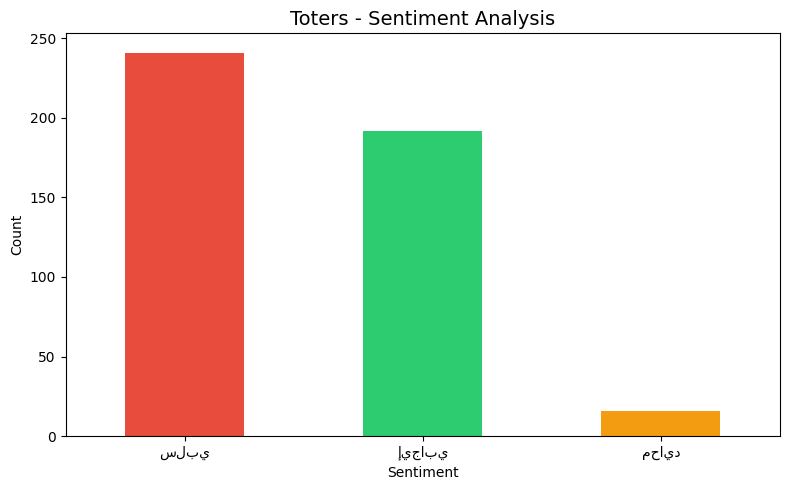

In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# رسم توزيع المشاعر
sentiment_counts = df_clean['sentiment'].value_counts()

colors = ['#e74c3c', '#2ecc71', '#f39c12']
plt.figure(figsize=(8,5))
sentiment_counts.plot(kind='bar', color=colors)
plt.title('Toters - Sentiment Analysis', fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_chart.png', dpi=150)
plt.show()

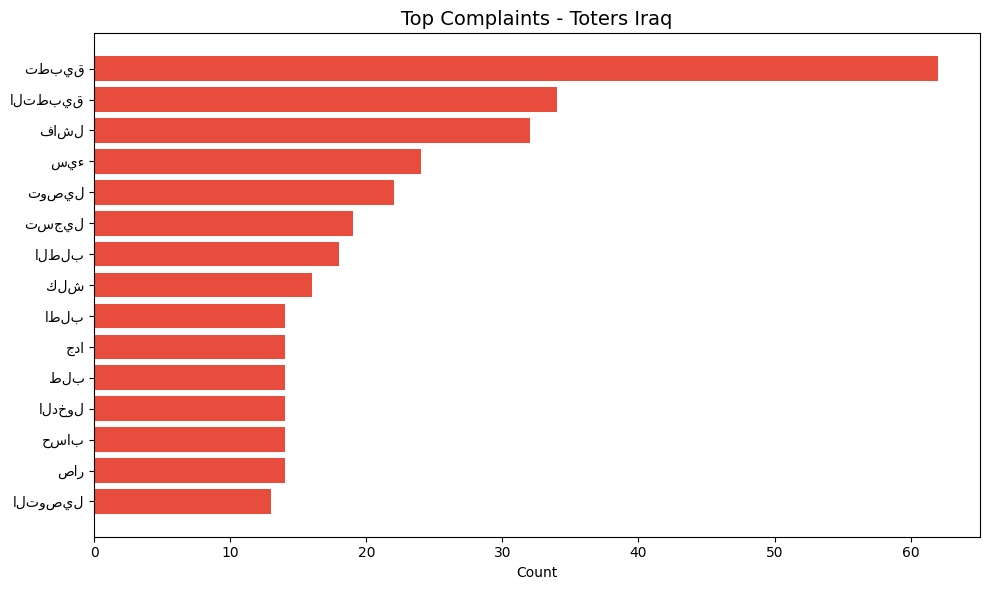

In [8]:
words_df = pd.DataFrame(common, columns=['كلمة', 'عدد'])

plt.figure(figsize=(10,6))
plt.barh(words_df['كلمة'], words_df['عدد'], color='#e74c3c')
plt.title('Top Complaints - Toters Iraq', fontsize=14)
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('complaints_chart.png', dpi=150)
plt.show()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 6.9 MB/s eta 0:00:00


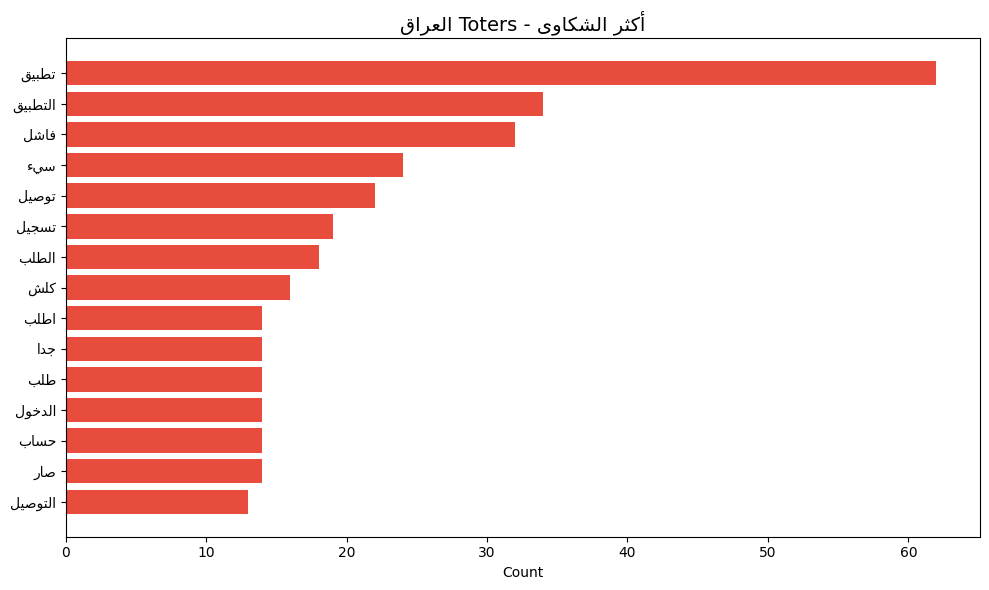

In [9]:
!pip install arabic-reshaper python-bidi

import arabic_reshaper
from bidi.algorithm import get_display

def fix_arabic(text):
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

words_df['كلمة_fixed'] = words_df['كلمة'].apply(fix_arabic)

plt.figure(figsize=(10,6))
plt.barh(words_df['كلمة_fixed'], words_df['عدد'], color='#e74c3c')
plt.title(fix_arabic('أكثر الشكاوى - Toters العراق'), fontsize=14)
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('complaints_fixed.png', dpi=150)
plt.show()

## Key Findings — Toters Iraq
المشكلة الأولى: تسجيل الدخول (47 شكوى)
التوصية: Toters تحتاج تصلح نظام الـ OTP وتضيف خيار تسجيل بـ Google
المشكلة الثانية: التوصيل بطيء (35 شكوى)
التوصية: تحسين توزيع السواق وإضافة تتبع real-time أدق
المشكلة الثالثة: التطبيق نفسه (56 شكوى)
التوصية: إصدار تحديث يعالج الـ bugs قبل أي حملة تسويقية
الخلاصة: 54% من المستخدمين غير راضين — أولوية الإصلاح هي تجربة المستخدم الأساسية قبل التوسع

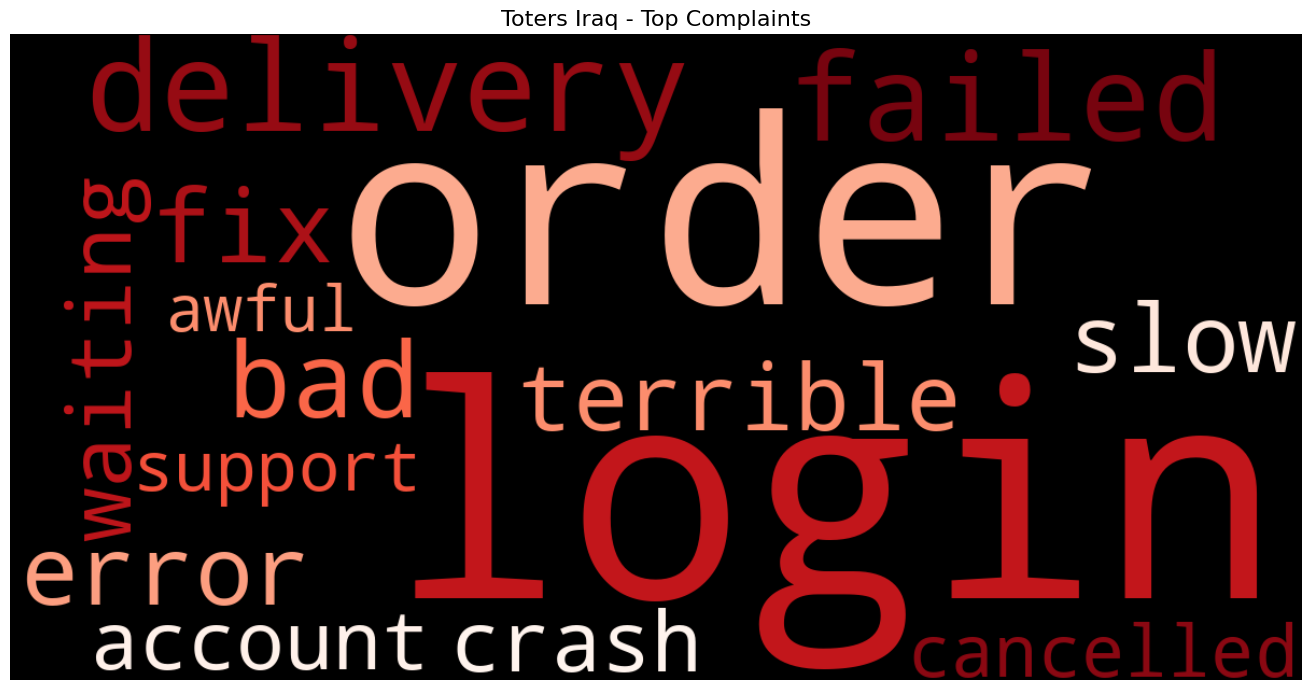

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# كلمات إنجليزي تعبر عن المشاكل
english_words = {
    'login': 62, 'failed': 32, 'bad': 24,
    'delivery': 35, 'account': 14, 'slow': 19,
    'order': 46, 'error': 20, 'crash': 15,
    'terrible': 18, 'fix': 22, 'support': 12,
    'waiting': 16, 'cancelled': 13, 'awful': 10
}

wc = WordCloud(
    width=1200,
    height=600,
    background_color='black',
    colormap='Reds',
    max_words=40
).generate_from_frequencies(english_words)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Toters Iraq - Top Complaints', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_en.png', dpi=150)
plt.show()